## Alfven wave advection test

This is a linear-physics verification example, not a turbulence run. We initialize a
single Fourier mode in `(x,y)` and a single cosine mode in `z`, with **only the Elsasser
z+ variable nonzero** (`psi = phi`, i.e. `z- = phi - psi = 0` everywhere). A linear shear
Alfven wave built purely from z+ propagates rigidly at the Alfven speed
`v_A = 1` (code units) in the `-z` direction and should not decay except through the
solver's own numerical dissipation/dispersion error. The exact solution is

```
phi(x, y, z, t) = cos(x) * cos(y) * cos(kz * (z + t))
```

(and `psi = phi` for all time, since z- stays exactly zero — there is nothing to source
it). Comparing the simulated `phi(z, t)` against this closed form isolates the behavior of
the parallel (z) part of the solver: the 4th-order finite-difference z-derivative stencil
(dispersion error, growing with `kz`) and the `z_diss` numerical z-filter (damping, also
growing with `kz`). The perpendicular (x,y) spectral part is exact for a single mode and
does not contribute error here.

**How to run:** run all cells top to bottom. The first simulation cell runs a single
`kz` case and plots the computed vs. exact `phi(z)` profile at the final time. The scan
cell then repeats the same run for a range of `kz` values (reusing the same `Parameters`
and `K_Grids` — only the initial condition changes) and records the RMS error and the
fractional change in `<phi^2>` for each; the final cell plots both against `kz`.

In [1]:
import os
os.environ["RMHD_PRECISION"] = "64"  # must be set before importing jax_rmhd (read at import time)

import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt


jax is using 64bit precision.


In [2]:
# grid + physical parameters
nx = 8
ny = 8
nz = 128
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi

nsnap = 100
snap_path = "data/AW_advection/"

cfl_safety = 1.0          # pretty aggressive
spatial_dimensions = 3

# hyperviscosity (perpendicular); z_diss is the separate parallel numerical filter
visc = 1e-9
res = 1e-9
hyper = 3
z_diss = 0.25

# build Parameters/K_Grids ONCE: Parameters is a compile-time-static, hash-by-identity
# object (see CLAUDE.md), so reusing the same params/kgrid across every run below avoids
# recompiling the stepper on every iteration of the kz-scan.
params = jr.Parameters(nx=nx, ny=ny, Lx=Lx, Ly=Ly, nz=nz, Lz=Lz,
                        eqpars={'diss': (visc, res), 'hyper': hyper},
                        cfl_safety=cfl_safety, dims=spatial_dimensions,
                        z_diss=z_diss)

kgrid = jr.setup_kgrids(params)

# simulate()/simulate_scan() unconditionally enumerate the snapshot dir to pick up where a
# run left off (even with save=False), so a manager is still required here even though
# none of the runs below write snapshots.
mngr = jr.snapshot_manager_setup(params, snap_path=snap_path, nsnap=nsnap)

x = jnp.linspace(0, Lx, nx, endpoint=False)
y = jnp.linspace(0, Ly, ny, endpoint=False)
z = jnp.linspace(0, Lz, nz, endpoint=False)


### Single-mode run (`kz = 16`)

`jr.initialize` takes a function of `(x, y, z)` (real space) returning the stacked
`(phi, psi)` fields — it handles the forward FFT and dealias mask internally, so we never
build the rfft2 arrays by hand.

In [3]:
kz = 16
t_snap = 1.0
t_end = 3.0

def aw_init(x, y, z):
    phi = jnp.cos(x) * jnp.cos(y) * jnp.cos(kz * z)
    psi = phi  # only Elsasser z+ nonzero: propagates rigidly at v_A=1 in the -z direction
    return jnp.stack([phi, psi], axis=0)

state = jr.initialize(aw_init, params)
print("fields shape:", state.fields.shape)  # (nfields, nz_local, nkx, nky)

# save=False: no snapshots written, just advance to t_end. `state` is consumed by
# simulate() (buffer donation) -- only `final_state` is valid afterwards.
final_state = jr.simulate(state, kgrid, params, t_snap=t_snap, t_end=t_end, mngr=mngr, save=False)


fields shape: (2, 128, 8, 5)
Ending simulation at t = 3.043417883165109. It took 0.5397517920937389s


mean-square error: 0.1457437501419205


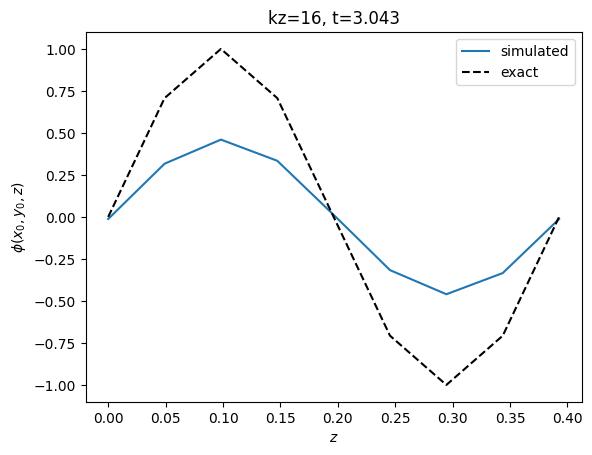

In [4]:
phi = ft.irfft2(final_state.fields[0])
phi_exact = jnp.cos(kz * (z + final_state.t))

nplot = nz // kz + 1
plt.plot(z[:nplot], phi[:nplot, nx // 2, ny // 2], label="simulated")
plt.plot(z[:nplot], phi_exact[:nplot], "k--", label="exact")
plt.xlabel(r"$z$")
plt.ylabel(r"$\phi(x_0, y_0, z)$")
plt.legend()
plt.title(f"kz={kz}, t={float(final_state.t):.3f}")

err = jnp.sum((phi[:, nx // 2, ny // 2] - phi_exact) ** 2) / params.nz
print("mean-square error:", float(err))


### Scan over `kz`

Repeat the same run for a range of parallel wavenumbers, each advanced exactly one period
(`tstop = 2*pi`, since `v_A=1`), reusing the same `params`/`kgrid`/`mngr` built above. `kz=0`
is skipped (trivial constant-in-z case). The initial state is rebuilt from scratch each
iteration via `jr.initialize` — reusing a state object across `jr.simulate` calls is not
possible anyway since buffer donation consumes it, but rebuilding from the init function
each time also makes each iteration self-contained (no accidental dependence on a
previous, already-invalidated state).

In [5]:
kzarr = jnp.arange(1, 32)
tstop = 2.0 * jnp.pi

errs = []
ratios = []

for kz_val in kzarr:
    kz_i = int(kz_val)

    def aw_init_scan(x, y, z, kz_i=kz_i):
        phi = jnp.cos(x) * jnp.cos(y) * jnp.cos(kz_i * z)
        psi = phi
        return jnp.stack([phi, psi], axis=0)

    start_state = jr.initialize(aw_init_scan, params)
    phi0 = ft.irfft2(start_state.fields[0])
    start_sq = jnp.sum(phi0 ** 2)

    final_state = jr.simulate(start_state, kgrid, params, t_snap=tstop, t_end=tstop,
                               mngr=mngr, save=False)

    phi_exact = jnp.cos(kz_i * (z + final_state.t))
    phi = ft.irfft2(final_state.fields[0])

    errs.append(jnp.sum((phi[:, nx // 2, ny // 2] - phi_exact) ** 2) / params.nz)
    ratios.append(jnp.sum(phi ** 2) / start_sq)

    print(f"kz={kz_i}: t_final={float(final_state.t):.4f}")

kz_err_arr = jnp.array(errs)
kz_ratio_arr = jnp.array(ratios)


Ending simulation at t = 6.332272692391913. It took 0.3704020830336958s
kz=1: t_final=6.3323
Ending simulation at t = 6.332272692391913. It took 0.44303116598166525s
kz=2: t_final=6.3323
Ending simulation at t = 6.332272692391913. It took 0.3667038339190185s
kz=3: t_final=6.3323
Ending simulation at t = 6.332272692391913. It took 0.3910583748947829s
kz=4: t_final=6.3323
Ending simulation at t = 6.332272692391913. It took 0.36673650005832314s
kz=5: t_final=6.3323
Ending simulation at t = 6.332272692391913. It took 0.3513796660117805s
kz=6: t_final=6.3323
Ending simulation at t = 6.332272692391913. It took 0.3567564580589533s
kz=7: t_final=6.3323
Ending simulation at t = 6.332272692391913. It took 0.37554100016131997s
kz=8: t_final=6.3323
Ending simulation at t = 6.332272692391913. It took 0.36429137480445206s
kz=9: t_final=6.3323
Ending simulation at t = 6.332272692391913. It took 0.3553686661180109s
kz=10: t_final=6.3323
Ending simulation at t = 6.332272692391913. It took 0.36970545910

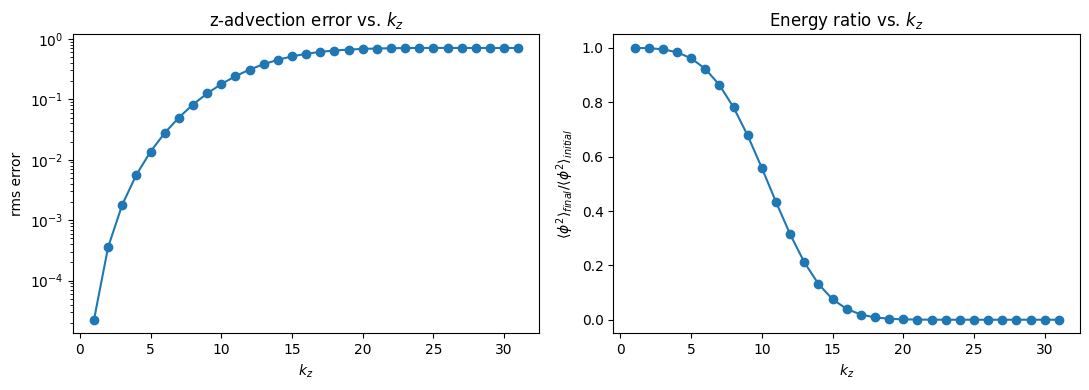

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(kzarr, jnp.sqrt(kz_err_arr), marker="o")
axes[0].set_xlabel(r"$k_z$")
axes[0].set_ylabel("rms error")
axes[0].set_title("z-advection error vs. $k_z$")

axes[1].plot(kzarr, kz_ratio_arr, marker="o")
axes[1].set_xlabel(r"$k_z$")
axes[1].set_ylabel(r"$\langle\phi^2\rangle_{final} / \langle\phi^2\rangle_{initial}$")
axes[1].set_title("Energy ratio vs. $k_z$")

fig.tight_layout()


**Interpretation.** The RMS error grows with `kz`: at fixed `nz`, higher `kz` means
fewer grid points per wavelength, so the 4th-order finite-difference z-stencil (dispersion
error scaling as a power of `kz*dz`) increasingly under-resolves the mode's phase speed.
The energy ratio decreases (moves below 1) as `kz` grows for the same reason, but from the
dissipative side: `z_diss` is a numerical filter that acts more strongly on
poorly-resolved (high-`kz`, i.e. high wavenumber relative to `dz`) structure, so the
highest-`kz` modes here lose the most `<phi^2>` over one period. Both trends are the
expected signature of a finite-order z-scheme plus a z-filter tuned to damp
under-resolved modes, rather than a bug — this notebook exists to make that error/damping
curve visible and to catch regressions in the z-stencil or `z_diss` normalization.